### This notebook compute "VSS3. Index of formalized irrigation water use rights" indicator for the 27 basins of IKI Project
Spanish: Índice de derechos de uso de agua de riego formalizados

**Created:** 10/10/2025 by Serena Gilson (sgilson@rti.org)  
**Project #:** 0219481  
**Last modified:** 9 Jan 2026  
**Status:**   
**QA Status:** reviewed by Scott Sheeder  
**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad
 
**Objective:**   
**Compatibility:**  
**Packages:** numpy, pandas, geopandas, sqlite3, matplotlib ...  
**Further documentation:**  
 
**Inputs:**   Shapefile of COMIDs and districts, DerehcosUsoAgua shapefile, Cobertura_Agricola shapefile from MINAM

**Outputs:** 
 
**Assumptions:** Assumptions involved in the shapefiles being used but this is the best estimate we have for now. Made an assumption that if the percentage is greater than 100 or less than 0.01, it is inaccurate and set to N/A instead of 0 so the calculation is not included in the risk calculation. 
 
**Future work:** Assumptions could perhaps be further tuned to determine which values to keep, which values to set to 0, and which values to set to N/A.
 
**Notes:** 

In [ ]:
## Steps for QC
# Verify that the first code cells follow this structure
# 1) import libraries
# 2) set up user and database path (this will eventually change based on how we set up the repo/distribute the input data)
# 3) set up indicator ID and get scenarios from the database - for now we are just populating the database for scenarios 1 and 2, but there should be commented lines to get all available scenarios from the database
# 4) define filepaths for input data (again this will eventually change so for now we want all the filepaths in one block to change later)

# Then verify that the rest of the code performs the intended calculations and outputs the expected results. You can run up until the sql insert which is the last three cells in the notebook.
# Make sure the code to perform the calculations is well-organized and commented for clarity.
# Add notes about the methodology, assumptions, and anything that sticks out about the results in the markdown block at the top of the page.
# Add any notes about NaN/0 handling in the markdown block under notes or assumptions
# Add a section in the markdown "QA performed by:" so that we know who checked and when 

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
#import matplotlib.patches as mpatches

In [9]:
#SETTINGS

#user = 'jmayo'
#user= 'cpickering'
user = 'ssheeder'
ScnID= 1 #Scenario ID -- 1: Baseline, 1981-2005, 2: Future, 2030, 3: Future: 2050
IndID= 403 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'

In [10]:
#INPUTS

subbasins_shapefile = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp'
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')

#read in numerator, derechos uso de agua agricola
DUA_agricola= gpd.read_file(f"C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/DerechoUsoAgua_23082024_agricola.shp")

#read in denominator, total agricultural area 
area_agricola= gpd.read_file(f"C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/GIS/2_USO_DE_SUELO_GEOLOGIA_LAND_USE_COVER/Superficie_Agricola/Cobertura_Agricola/Peru_cober_Aagri_Dist_geowgs84.shp")


In [11]:
#CALCULATIONS

# Spatial join DUA_agricola points to subbasins to assign COMID and add a new COMID column
DUA_agricola = DUA_agricola.to_crs(subbasins_gdf.crs)
DUA_agricola_with_comid = gpd.sjoin(
    DUA_agricola, 
    subbasins_gdf[['COMID', 'geometry']], 
    how='left', 
    predicate='intersects'
)

# Ensure all shapefiles are in the same CRS
DUA_agricola = DUA_agricola.to_crs(subbasins_gdf.crs)
area_agricola = area_agricola.to_crs(subbasins_gdf.crs)

# Spatial join DUA_agricola points to subbasins to assign COMID
DUA_joined = gpd.sjoin(DUA_agricola, subbasins_gdf[['COMID', 'geometry']], how='inner', predicate='intersects')

# Sum DUA 'Area' (hectares) for each COMID
DUA_area_by_comid = DUA_joined.groupby('COMID_right')['Area'].sum().reset_index()
DUA_area_by_comid = DUA_area_by_comid.rename(columns={'Area': 'area_DUA_ha', 'COMID_right': 'COMID'})

# Intersect area_agricola polygons with subbasins to assign COMID and get area within each COMID
agri_intersect = gpd.overlay(area_agricola, subbasins_gdf[['COMID', 'geometry']], how='intersection')
agri_intersect['area_agri_ha'] = agri_intersect.geometry.area / 10000  # convert m² to hectares

# Sum agricultural area (hectares) for each COMID
agri_area_by_comid = agri_intersect.groupby('COMID')['area_agri_ha'].sum().reset_index()

# Merge the two area tables
DUA_area_ratio = pd.merge(DUA_area_by_comid, agri_area_by_comid, on='COMID', how='outer').fillna(0)

# Calculate proportion and multiply by 100
DUA_area_ratio['proportion_DUA'] = np.where(
    DUA_area_ratio['area_agri_ha'] > 0,
    (DUA_area_ratio['area_DUA_ha'] / DUA_area_ratio['area_agri_ha']) * 100,
    np.nan
)

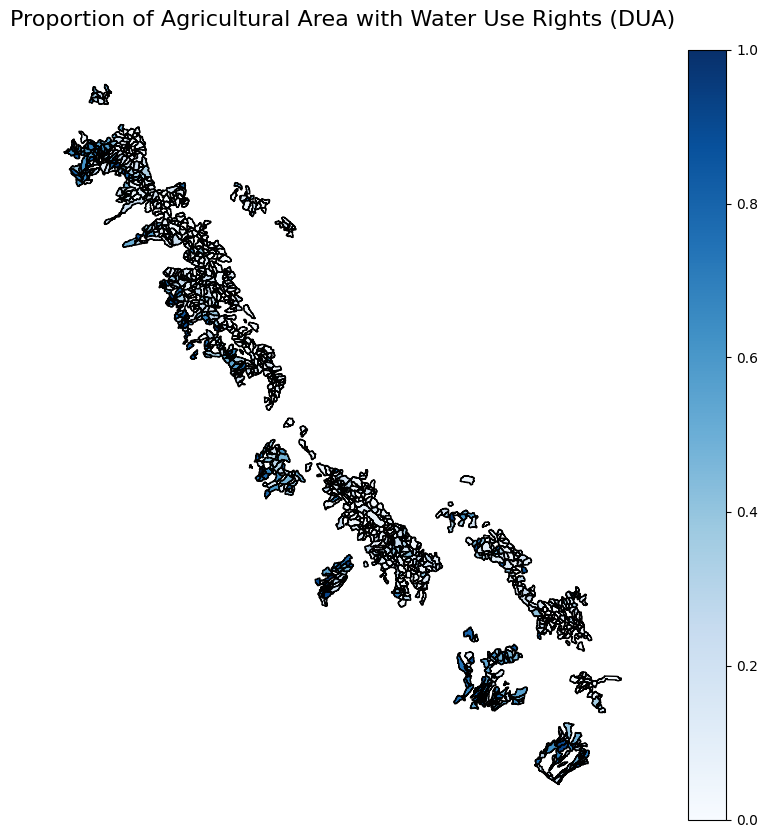

In [12]:
#ROUNDING, NA HANDLING, ETC.

# Calculate proportion (as decimal between 0 and 1)
DUA_area_ratio['proportion_DUA'] = np.where(
    DUA_area_ratio['area_agri_ha'] > 0,
    (DUA_area_ratio['area_DUA_ha'] / DUA_area_ratio['area_agri_ha']),
    np.nan
)

# If proportion is greater than 1.0 or less than 0.0001, set to N/A
DUA_area_ratio['proportion_DUA'] = np.where(
    (DUA_area_ratio['proportion_DUA'] > 1.0) | (DUA_area_ratio['proportion_DUA'] < 0.0001),
    np.nan,
    DUA_area_ratio['proportion_DUA']
)

# Round to 2 decimal places
DUA_area_ratio['proportion_DUA'] = DUA_area_ratio['proportion_DUA'].round(2)

# Merge with subbasins_gdf to get the final geodataframe
subbasins_gdf = subbasins_gdf.merge(DUA_area_ratio[['COMID', 'proportion_DUA']], on='COMID', how='left')

#PLOT

# Plot the results
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
subbasins_gdf.plot(column='proportion_DUA', ax=ax, legend=True, cmap='Blues', edgecolor='black')
ax.set_title('Proportion of Agricultural Area with Water Use Rights (DUA)', fontsize=16)
plt.axis('off')
plt.show()

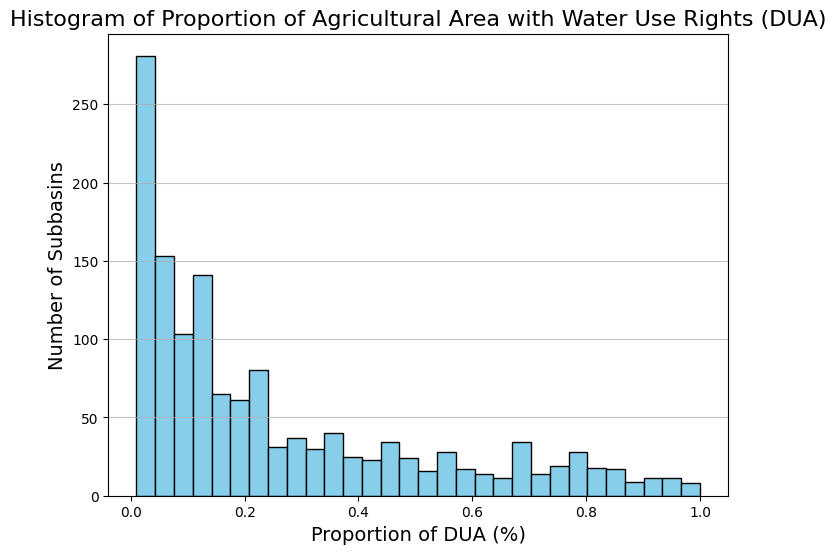

In [ ]:
#create histogram of proportion_DUA excluding zeros
plt.figure(figsize=(8,6))
plt.hist(subbasins_gdf.loc[subbasins_gdf['proportion_DUA'] > 0, 'proportion_DUA'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Proportion of Agricultural Area with Water Use Rights (DUA)', fontsize =16)
plt.xlabel('Proportion of DUA (%)', fontsize=14)
plt.ylabel('Number of Subbasins', fontsize=14)
plt.grid(axis='y', alpha=0.75)
plt.show()

SQLITE INSERT 

In [18]:
#Update relevant dataframe and value column from the calculations above for the specific indicator
insert_data= subbasins_gdf #COMID
value_column= 'proportion_DUA'

In [19]:
# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Fixed IndID and ScnID (update above)

#For now I am commenting out the looping of scenarios as I imagine we might run just baseline scenarios for now.
# Define the mapping between scenario and DataFrame column
# scenario_columns = {
#     1: 'ACTUAL ANUAL',
#     2: '2030 ANUAL',
#     3: '2050 ANUAL'
# }

# Prepare list of rows to insert
rows_to_insert = []

#for scn_id, column_name in scenario_columns.items():
for _, row in insert_data.iterrows():
    comid = row['COMID']
    value = row[value_column]
    #normalized_value = None  # or compute something like: value / max_value #took out normalized value from the table for now
    rows_to_insert.append((ScnID, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""


In [20]:
rows_to_insert

[(1, 403, 311153600, 0.8884601090643214),
 (1, 403, 310832400, 0.026190945849738374),
 (1, 403, 310825700, 0.0),
 (1, 403, 310282400, 88.87028188557207),
 (1, 403, 308754600, 0.0),
 (1, 403, 307736500, 0.0),
 (1, 403, 307078200, 31.612504271028286),
 (1, 403, 307183500, 0.0),
 (1, 403, 306538400, 30.5928782440371),
 (1, 403, 306599700, 49.6405712464289),
 (1, 403, 306319300, 22.03883456519281),
 (1, 403, 306030000, 13.608984983291203),
 (1, 403, 305746400, 0.0),
 (1, 403, 311953100, 0.0),
 (1, 403, 304273900, 0.0),
 (1, 403, 304281100, 0.0),
 (1, 403, 304281200, 0.0),
 (1, 403, 304379300, 0.0),
 (1, 403, 304274000, 0.0),
 (1, 403, 304313700, 0.0),
 (1, 403, 304306400, 0.0),
 (1, 403, 304327700, 0.0),
 (1, 403, 304313800, 0.0),
 (1, 403, 304306300, 0.0),
 (1, 403, 304321600, 0.0),
 (1, 403, 304321700, 0.0),
 (1, 403, 304339400, 0.0),
 (1, 403, 304335700, 0.0),
 (1, 403, 304343200, 0.0),
 (1, 403, 304343100, 0.0),
 (1, 403, 304335800, 0.0),
 (1, 403, 304343000, 0.0),
 (1, 403, 304330900,

In [21]:
# Check for duplicates in the input dataframe before insert
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:", df_check[duplicates])

Duplicates in rows_to_insert: Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [22]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()